#Task 1: Vectorized Scaled Dot-Product Attention from Scratch
###Objective

To implement the scaled dot-product attention mechanism from scratch using optimized linear algebra operations, with batch-wise multi-head processing, causal sequence masking, and scaling using 4D matrix operations.

###Technologies / Tools Used

Python,
NumPy,
Matplotlib,
Google Colab,




### Formula

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

#Step 1: Import Required Libraries

Import the libraries required for the implementation.

NumPy is used for matrix operations, and Matplotlib is used for visualization.

In [5]:
# Import NumPy for matrix operations
import numpy as np

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Set random seed for consistent results
np.random.seed(42)

#Step 2: Define Input Dimensions

Define the batch size, number of attention heads, sequence length, and head dimension.

These values define the size of our 4D input matrices.

In [6]:
# Define input dimensions
batch_size = 2
num_heads = 2
sequence_length = 4
d_k = 4

print("Batch size:", batch_size)
print("Number of heads:", num_heads)
print("Sequence length:", sequence_length)
print("Head dimension:", d_k)

Batch size: 2
Number of heads: 2
Sequence length: 4
Head dimension: 4


#Step 3: Create Q, K and V

Create the Query, Key, and Value matrices.

Q, K, and V are the three main matrices used in the attention mechanism.

In [7]:
# Create Query matrix
Q = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    d_k
)

# Create Key matrix
K = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    d_k
)

# Create Value matrix
V = np.random.randn(
    batch_size,
    num_heads,
    sequence_length,
    d_k
)

# Display the shapes
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

Q shape: (2, 2, 4, 4)
K shape: (2, 2, 4, 4)
V shape: (2, 2, 4, 4)


#Step 4: Calculate Attention Scores

Calculate QK^T


The attention scores determine how much each token should attend to other tokens.

In [8]:
# Transpose the last two dimensions of K
K_transpose = np.swapaxes(K, -1, -2)

# Calculate Q × K^T
scores = np.matmul(Q, K_transpose)

print("Attention scores shape:", scores.shape)

Attention scores shape: (2, 2, 4, 4)


#Step 5: Apply Scaling

Divide the attention scores by sqrroot of dk
	​

Scaling keeps the attention scores in a suitable range before applying softmax.

In [9]:
# Scale the attention scores by √d_k
scores = scores / np.sqrt(d_k)

#Step 6: Apply Causal Masking

Prevent tokens from attending to future tokens.

A causal mask allows each token to attend only to itself and previous tokens.

In [10]:
# Create a lower triangular causal mask
mask = np.tril(
    np.ones(
        (sequence_length, sequence_length)
    )
)

# Block future tokens
scores = np.where(
    mask == 1,
    scores,
    -np.inf
)

#Step 7: Apply Softmax

Convert the attention scores into attention weights.

Softmax converts the scores into probabilities.

In [11]:
# Subtract the maximum value for numerical stability
scores = scores - np.max(
    scores,
    axis=-1,
    keepdims=True
)

# Calculate exponential values
exp_scores = np.exp(scores)

# Convert scores into attention weights
attention_weights = exp_scores / np.sum(
    exp_scores,
    axis=-1,
    keepdims=True
)

print("Attention weights calculated.")

Attention weights calculated.


#Step 8: Calculate Attention Output

Multiply the attention weights by V.

The resulting matrix is the final attention output.

In [12]:
# Calculate the final attention output
output = np.matmul(
    attention_weights,
    V
)

print("Attention output shape:", output.shape)

Attention output shape: (2, 2, 4, 4)


#Step 9: Visualize Attention Weights

Display the attention weights using a heatmap.

A heatmap provides a visual representation of how tokens attend to each other.

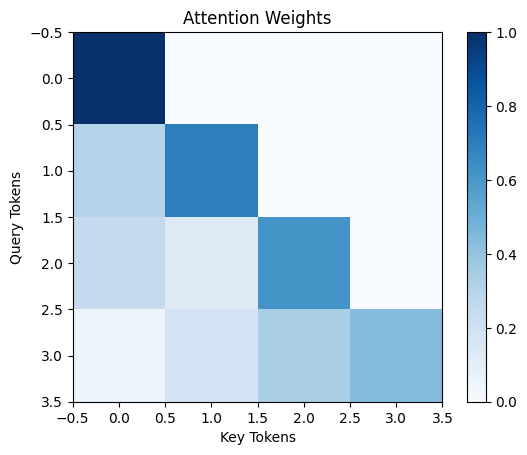

In [13]:
# Select the first batch and first attention head
attention_matrix = attention_weights[0, 0]

# Create the heatmap
plt.imshow(
    attention_matrix,
    cmap="Blues"
)

# Add labels
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.title("Attention Weights")

# Display color scale
plt.colorbar()

# Show the visualization
plt.show()

#Step 10: Display Results

Display the shapes of the input and output matrices.

This confirms that the attention operation was performed on the required 4D inputs.

In [14]:
# Display final shapes
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)
print("Attention weights shape:", attention_weights.shape)
print("Output shape:", output.shape)

Q shape: (2, 2, 4, 4)
K shape: (2, 2, 4, 4)
V shape: (2, 2, 4, 4)
Attention weights shape: (2, 2, 4, 4)
Output shape: (2, 2, 4, 4)


#Conclusion

The scaled dot-product attention mechanism was successfully implemented using Python and NumPy. The implementation includes multi-head 4D inputs, scaling, causal masking, softmax, attention output calculation, and visualization of the attention weights.